# 07 — Temporal-order stress test (Phase 6, evaluation only)

**Owner:** M3 · **Question:** do the models actually depend on the **order** of the sounds?

**Method.**
- Each validation clip's word is located with the centred energy window on the **original** audio.
- That window is then played unchanged, **reversed**, or **shuffled**: cut into ~100 ms chunks and replayed in a random order (`src/stress.py`).
- So every variant contains the same sounds, and only their order changes.
- Each model computes its own features from the perturbed audio, and classifies it with its **final, unchanged** trained weights. Nothing is retrained on perturbed data.

**What each model should do.**
- A1 pools its frames into clip statistics. Its static MFCC statistics are exactly unchanged by reversal. Its Δ and ΔΔ channels, however, describe the direction of spectral change over ~90 ms, and reversal flips their sign. So A1 is order-free only beyond ~90 ms.
- To isolate that, we add an **order-free control**: the same logistic regression refit on the static MFCC statistics alone. It must not change when the audio is reversed.
- Models that use order (A2 HMM, A3 recurrent, A4 convolutional) should collapse, above all on *tisa*/*sita*. Reversed *tisa* is roughly "a-sit", so they should hear *sita*.
- Shuffling keeps the order inside each 100 ms chunk, but the cuts create small discontinuities. The control's drop under shuffling measures that artifact.

**Sanity check.** On the `original` variant, every model must reproduce its logged validation accuracy exactly. This proves the perturbation pipeline matches the one each model was trained with.

A5 is scored with the checkpoint of its final configuration (run A5-R3-01, seed 42). The R2 runs save no checkpoints, at 1.2 GB each. If that file is missing, A5 is left out.

In [1]:
import glob, os, shutil, sys, subprocess

REPO_URL = "https://github.com/Hassan-Adelani-Luqman/nlp-sequential-modeling-group21.git"
REPO_DIR = "nlp-sequential-modeling-group21"
if os.path.isdir("/kaggle/input") or "google.colab" in sys.modules:
    # A code-snapshot dataset attached on Kaggle takes precedence over GitHub (lets you run code before it is pushed).
    snapshot = glob.glob("/kaggle/input/**/src/train_torch.py", recursive=True) if os.path.isdir("/kaggle/input") else []
    zipped = glob.glob("/kaggle/input/**/group21-code*.zip", recursive=True) if os.path.isdir("/kaggle/input") else []
    if not snapshot and zipped:  # the archive was not unpacked on upload: unpack it ourselves
        import zipfile
        zipfile.ZipFile(zipped[0]).extractall("/tmp/snapshot")
        snapshot = glob.glob("/tmp/snapshot/**/src/train_torch.py", recursive=True)
    if snapshot:
        REPO_DIR = "/tmp/" + REPO_DIR   # outside /kaggle/working, so only results are saved as outputs
        if not os.path.isdir(REPO_DIR):
            shutil.copytree(os.path.dirname(os.path.dirname(snapshot[0])), REPO_DIR)
        print("using code snapshot:", os.path.dirname(os.path.dirname(snapshot[0])))
    elif not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "-q", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    if os.path.isdir("/kaggle/working"):
        # Kaggle writes outputs to /kaggle/working, which starts empty: seed it with the repo's logged runs
        # (and any checkpoints shipped with the code snapshot) so finished runs are reused, not retrained.
        for folder in ("results", "checkpoints"):
            if os.path.isdir(folder):
                shutil.copytree(folder, os.path.join("/kaggle/working", folder), dirs_exist_ok=True)
        os.environ.setdefault("SWN_CACHE_DIR", "/tmp/swn_feature_cache")  # recomputable: keep it out of the outputs
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

In [2]:
import json, pickle, platform
import numpy as np, pandas as pd, torch, yaml
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

from src.data import label_names, load_splits
from src.evaluate import compute_metrics, pair_confusion, softmax
from src.features import Standardizer, cached_features, utterance_cmvn
from src.models.baselines import GMMHMMClassifier, make_a1
from src.models.bilstm import BiLSTMAttention
from src.models.tcresnet import TCResNet
from src.models.wav2vec2 import Wav2Vec2Classifier
from src.paths import CONFIGS_DIR, REPO_ROOT, checkpoints_dir, results_dir
from src.plotting import INK_SECONDARY, SERIES, apply_style, save_figure
from src.stress import PERTURBATIONS, perturbed_features
from src.train_torch import load_checkpoint, predict_logits

apply_style()
torch.set_num_threads(os.cpu_count() or 4)
NAMES = label_names()
splits = load_splits()
train, val = splits["train"], splits["val"]
y_tr, y_val = train.label_id.to_numpy(), val.label_id.to_numpy()
print(f"val {len(val)} clips · Python {platform.python_version()} · torch {torch.__version__}")


def logged(exp_id, seed=42):
    '''The logged record of a run (params, extra, metrics) from results/ or the repo copy.'''
    for base in (results_dir(), REPO_ROOT / "results"):
        f = base / "metrics" / f"{exp_id}_seed{seed}_val.json"
        if f.exists():
            return json.loads(f.read_text(encoding="utf-8"))
    raise FileNotFoundError(exp_id)


def checkpoint(name):
    '''A saved model file from the output folder, or the repo's checkpoints/ if the output folder has none.'''
    candidates = [checkpoints_dir() / name, REPO_ROOT / "checkpoints" / name]
    return next((c for c in candidates if c.exists()), candidates[0])


def variants(feat):
    '''Validation features for the three variants, computed from the (perturbed) audio.'''
    assert feat["crop"] == "energy", "src.stress locates the word with the energy window only"
    kw = {"n_mfcc": feat["n_mfcc"]} if "n_mfcc" in feat else {}
    return {kind: perturbed_features(val.path, kind, feat["feature"], feat["seconds"], **kw) for kind in PERTURBATIONS}

val 630 clips · Python 3.14.3 · torch 2.14.0+cpu


## Build a predictor for each final model

In [3]:
predictors = {}   # name -> (exp_id, {variant: probabilities})

# A1: logistic regression on order-free MFCC-13 statistics (deterministic: refit exactly as logged)
a1 = logged("A1-R0-03")
feat = a1["params"]["features"]
clf = make_a1(a1["params"]["kind"]).set_params(clf__C=a1["extra"]["best_params"]["C"]).fit(cached_features(train, **feat), y_tr)
V1 = variants(feat)
predictors["A1 MFCC stats + LR"] = ("A1-R0-03", {k: clf.predict_proba(X) for k, X in V1.items()})

# Order-free control: the same classifier on the static MFCC statistics only (no deltas). The feature vector is
# [mean | std | min | max] over 39 channels each (13 static, 13 delta, 13 delta-delta).
n_ch = V1["original"].shape[1] // 4
static = [b * n_ch + i for b in range(4) for i in range(feat["n_mfcc"])]
ctrl = make_a1(a1["params"]["kind"]).set_params(clf__C=a1["extra"]["best_params"]["C"]).fit(
    cached_features(train, **feat)[:, static], y_tr)
CONTROL = "A1 static MFCCs only (control)"
control_probs = {k: ctrl.predict_proba(X[:, static]) for k, X in V1.items()}
spread = V1["original"].std(0) + 1e-9
for k in ("reversed", "shuffled"):
    moved = np.abs(V1[k] - V1["original"]) / spread
    print(f"{k}: A1 features move by {moved[:, static].mean():.2f} SD (static statistics) and "
          f"{np.delete(moved, static, axis=1).mean():.2f} SD (delta statistics) on average")

# A2: 12-state x 8-Gaussian GMM-HMM (refit once, then cached as a pickle next to the neural checkpoints)
a2 = logged("A2-R2-03")
feat = a2["params"]["features"]
hmm_file = checkpoint("A2-R2-03_seed42_hmm.pkl")
tr_seqs = utterance_cmvn(list(cached_features(train, **feat)))
scaler = Standardizer().fit(tr_seqs)
if hmm_file.exists():
    hmm = pickle.loads(hmm_file.read_bytes())
else:
    print("fitting the A2 GMM-HMM (about 10 minutes on CPU)...")
    hmm = GMMHMMClassifier(n_states=a2["params"]["n_states"], n_mix=a2["params"]["n_mix"], seed=42).fit(scaler.transform(tr_seqs), y_tr)
    hmm_file.parent.mkdir(parents=True, exist_ok=True)
    hmm_file.write_bytes(pickle.dumps(hmm))
T2 = a2["extra"]["temperature"]
predictors["A2 GMM-HMM"] = ("A2-R2-03", {k: softmax(hmm.scores(scaler.transform(utterance_cmvn(list(X)))), T2)
                                         for k, X in variants(feat).items()})

reversed: A1 features move by 0.00 SD (static statistics) and 0.39 SD (delta statistics) on average
shuffled: A1 features move by 0.09 SD (static statistics) and 1.10 SD (delta statistics) on average


In [4]:
def neural(exp_id, build):
    '''Probabilities of a saved neural checkpoint on the three variants (temperature from its logged run).'''
    rec = logged(exp_id)
    cfg = rec["params"]
    model, scaler, _ = load_checkpoint(checkpoint(f"{exp_id}_seed42.pt"), lambda: build(cfg))
    # in batches: a whole split at once needs several GB for A5's raw-waveform encoder
    return {k: softmax(predict_logits(model, X, scaler, batch_size=32), rec["extra"]["temperature"])
            for k, X in variants(cfg["features"]).items()}


n_feat = lambda cfg: 64 if cfg["features"]["feature"] == "logmel" else 3 * cfg["features"]["n_mfcc"]
predictors["A3 BiLSTM + attention (final)"] = ("A3-R2-12", neural("A3-R2-12", lambda c: BiLSTMAttention(n_features=n_feat(c), **c["model"])))
predictors["A3 recurrent only"] = ("A3-R2-11", neural("A3-R2-11", lambda c: BiLSTMAttention(n_features=n_feat(c), **c["model"])))
a4_best = yaml.safe_load((CONFIGS_DIR / "a4_best.yaml").read_text(encoding="utf-8"))["exp_id"]
predictors["A4 TC-ResNet"] = (a4_best, neural(a4_best, lambda c: TCResNet(n_features=n_feat(c), **c["model"])))
A5_RUN = "A5-R3-01"   # the final A5 configuration, seed 42
if checkpoint(f"{A5_RUN}_seed42.pt").exists():
    backbone = logged(A5_RUN)["params"]["model"]["backbone"]
    name = "A5 " + {"xlsr-300m": "XLS-R", "wav2vec2-base": "wav2vec2-base"}.get(backbone, backbone)
    predictors[name] = (A5_RUN, neural(A5_RUN, lambda c: Wav2Vec2Classifier(**c["model"], pretrained=False)))
else:
    print(f"{A5_RUN}_seed42.pt not found: A5 is left out (download it from the A5 Kaggle kernel's output)")
print("models:", {k: v[0] for k, v in predictors.items()})

C:\Users\Luqma\dev\projects\coursework\nlp-sequential-modeling-group21\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


models: {'A1 MFCC stats + LR': 'A1-R0-03', 'A2 GMM-HMM': 'A2-R2-03', 'A3 BiLSTM + attention (final)': 'A3-R2-12', 'A3 recurrent only': 'A3-R2-11', 'A4 TC-ResNet': 'A4-R2-05', 'A5 XLS-R': 'A5-R3-01'}


## Results

In [5]:
rows = []
for kind in PERTURBATIONS:
    m = compute_metrics(y_val, control_probs[kind], NAMES)
    rows.append({"model": CONTROL, "run": "(control, not logged)", "variant": kind, "accuracy": m["accuracy"],
                 "log_loss": m["log_loss"], "tisa/sita": pair_confusion(y_val, control_probs[kind].argmax(1), NAMES, "tisa", "sita"),
                 "matches_logged": None})
for name, (exp_id, probs) in predictors.items():
    logged_acc = logged(exp_id)["metrics"]["accuracy"]
    for kind in PERTURBATIONS:
        m = compute_metrics(y_val, probs[kind], NAMES)
        rows.append({"model": name, "run": exp_id, "variant": kind, "accuracy": m["accuracy"], "log_loss": m["log_loss"],
                     "tisa/sita": pair_confusion(y_val, probs[kind].argmax(1), NAMES, "tisa", "sita"),
                     "matches_logged": abs(m["accuracy"] - logged_acc) < 1e-9 if kind == "original" else None})
stress = pd.DataFrame(rows)
(results_dir() / "metrics").mkdir(parents=True, exist_ok=True)
stress.to_csv(results_dir() / "metrics" / "order_stress_test.csv", index=False)
logged_rows = stress.variant.eq("original") & stress.run.ne("(control, not logged)")
assert stress.loc[logged_rows, "matches_logged"].all(), "original-variant accuracy differs from the logged run"
print("sanity check passed: every model reproduces its logged validation accuracy on the original clips")

ORDER = [CONTROL, *predictors]
wide = stress.pivot(index="model", columns="variant", values="accuracy")[list(PERTURBATIONS)].loc[ORDER]
wide["drop when reversed"] = wide["original"] - wide["reversed"]
wide["drop when shuffled"] = wide["original"] - wide["shuffled"]
display(wide.style.format("{:.1%}"))
display(stress.pivot(index="model", columns="variant", values="tisa/sita")[list(PERTURBATIONS)].loc[ORDER]
        .style.format("{:.1%}").set_caption("tisa/sita confusion"))

# Direction of the tisa/sita errors on reversed audio: does reversed "tisa" (~"a-sit") become "sita"?
ti, si = NAMES.index("tisa"), NAMES.index("sita")
direction = pd.DataFrame({name: {"tisa heard as sita": (p["reversed"].argmax(1)[y_val == ti] == si).mean(),
                                 "sita heard as tisa": (p["reversed"].argmax(1)[y_val == si] == ti).mean()}
                          for name, p in [(CONTROL, control_probs), *[(n, pr) for n, (_, pr) in predictors.items()]]}).T
display(direction.style.format("{:.0%}").set_caption("reversed audio: tisa/sita errors by direction"))

sanity check passed: every model reproduces its logged validation accuracy on the original clips


variant,original,reversed,shuffled,drop when reversed,drop when shuffled
model,,,,,
A1 static MFCCs only (control),57.5%,57.5%,55.2%,0.0%,2.2%
A1 MFCC stats + LR,77.9%,50.2%,24.9%,27.8%,53.0%
A2 GMM-HMM,95.2%,38.6%,60.8%,56.7%,34.4%
A3 BiLSTM + attention (final),97.0%,20.8%,38.1%,76.2%,58.9%
A3 recurrent only,97.0%,27.3%,52.2%,69.7%,44.8%
A4 TC-ResNet,97.1%,28.7%,31.9%,68.4%,65.2%
A5 XLS-R,97.9%,30.5%,88.9%,67.5%,9.0%


variant,original,reversed,shuffled
model,,,
A1 static MFCCs only (control),20.0%,20.0%,21.0%
A1 MFCC stats + LR,6.7%,26.7%,8.6%
A2 GMM-HMM,0.0%,82.9%,27.6%
A3 BiLSTM + attention (final),0.0%,70.5%,26.7%
A3 recurrent only,0.0%,70.5%,35.2%
A4 TC-ResNet,0.0%,44.8%,18.1%
A5 XLS-R,0.0%,61.9%,15.2%


,tisa heard as sita,sita heard as tisa
A1 static MFCCs only (control),23%,17%
A1 MFCC stats + LR,48%,6%
A2 GMM-HMM,83%,83%
A3 BiLSTM + attention (final),69%,72%
A3 recurrent only,79%,62%
A4 TC-ResNet,52%,38%
A5 XLS-R,62%,62%


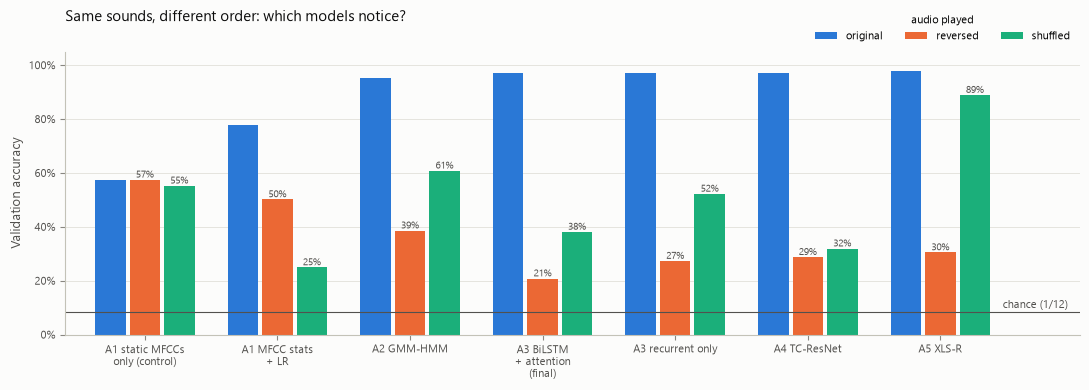

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
width = 0.26
x = np.arange(len(ORDER))
colors = dict(zip(PERTURBATIONS, SERIES[:3]))
for i, kind in enumerate(PERTURBATIONS):
    vals = wide[kind].to_numpy()
    xs = x + (i - 1) * width
    ax.bar(xs, vals, width=width - 0.03, color=colors[kind], label=kind)
    if kind != "original":   # label the perturbed bars; the original accuracies are in the table above
        for xi, v in zip(xs, vals):
            ax.text(xi, v, f"{v:.0%}", ha="center", va="bottom", fontsize=7.5, color=INK_SECONDARY)
ax.axhline(1 / 12, color=INK_SECONDARY, lw=0.8)
ax.annotate("chance (1/12)", (x[-1] + 0.47, 1 / 12), xytext=(0, 3), textcoords="offset points", ha="left", fontsize=8,
            color=INK_SECONDARY)
ax.set_xticks(x, [n.replace(" (final)", "\n(final)").replace(" + ", "\n+ ").replace(" only (control)", "\nonly (control)")
                  for n in ORDER], fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_xlim(-0.6, x[-1] + 1.05)                       # room at the right for the chance label
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_ylabel("Validation accuracy")
ax.grid(axis="x", visible=False)
ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.0), title="audio played", title_fontsize=8, ncol=3, frameon=False)
ax.set_title("Same sounds, different order: which models notice?", loc="left", pad=22)
fig.tight_layout()
save_figure(fig, "order_stress_test")
plt.show()

**Observations → next step (order stress test)**
- **The control behaves as designed.** Reversal leaves the static-statistics model exactly unchanged: 57.5% before and after, and its features move by 0.00 SD. Shuffling costs it 2.2 points, which is the artifact of the cuts between chunks.
- **Every model that uses order collapses on reversed audio,** although it hears exactly the same sounds.
  - A2 falls from 95.2% to 38.6%, A3 from 97.0% to 20.8% (27.3% without the convolutional front-end), A4 from 97.1% to 28.7%, and A5 from 97.9% to 30.5%.
  - All stay above chance (8.3%), so some evidence survives in the frame spectra themselves. But most of their accuracy depends on the order of the sounds.
  - Recurrence, convolution and self-attention depend on order to a similar degree: A3, A4 and A5 lose 67–76 points (the HMM: 57).
- **Reversal turns *tisa* into *sita*.** On reversed audio, the order-aware models confuse the anagram pair 45–83% of the time, against 0% on the original clips. The control stays at 20%.
  - The HMM does this most cleanly, and symmetrically: 83% of reversed *tisa* clips are heard as *sita*, and 83% of reversed *sita* clips as *tisa*. A5 is also symmetric, at 62% each way.
  - That is what a model reading the sounds in order should do. Reversed *tisa* is roughly "a-sit", and reversed *sita* roughly "a-tis".
- **A5 is the exception when the audio is shuffled.** Cut into 100 ms chunks and replayed in random order, A5 still reaches 88.9%, a drop of only 9 points. A2–A4 fall to 32–61%.
  - Reversal also reverses the order *inside* each chunk, and that destroys A5. So A5 relies on local order, the transitions between sounds within about 100 ms.
  - It hardly relies on how those pieces are arranged: it recognises the word from a set of locally ordered pieces.
  - A5 reads the raw waveform and computes no Δ features, so the cuts affect it less than the MFCC-based models (next points). Its 9-point drop includes whatever effect the cuts have, so it is an upper bound on how much A5 uses order beyond 100 ms.
- **A1 is not fully order-free.** Its Δ and ΔΔ statistics describe the direction of change over ~90 ms, and reversal costs A1 28 points. So part of the A1-vs-A2 gap is local, sub-word order, not only word-level order.
- **For the MFCC-based models, shuffling is the less clean test.** The cuts distort their Δ features: A1's delta statistics move by 1.10 SD under shuffling, against 0.39 SD under reversal. Their drops under shuffling therefore mix the loss of order with the artifact.
  - Within that caveat: A2 and the purely recurrent A3 keep more under shuffling (61%, 52%) than under reversal (39%, 27%). A4 is hurt about equally by both (29%, 32%).
- **Caveats.**
  - Log loss on the original clips differs slightly from the logged runs (A4: 0.118 vs 0.119), because this test applies each run's single fitted temperature rather than the cross-fitted ones. Accuracy matches exactly for every model, which is the check.
  - A5 is scored with the checkpoint of its final configuration's seed-42 run (A5-R3-01), which reproduces A5-R2-03 exactly.
- **→ Next:** vary the chunk length (for example 50–400 ms) to find the time scale at which A5 starts to depend on order. In the error analysis (Phase 8), check whether the order-aware models' remaining errors are clips whose word is unusually short or long.